# Latent Diffusion Super-Resolution for 7T fMRI-EPIRestoring k-space truncated fMRI-EPI slices with a channel-conditioned Stable DiffusionUNet (LoRA), followed by k-space data consistency.This is a companion experiment to[`ddpm-ddrm-fmri-superres`](https://github.com/ozgursntrk/ddpm-ddrm-fmri-superres), whichsolved the same inverse problem with a from-scratch DDPM prior and DDRM. The degradationoperator, data split, and metric space are kept identical so the two are directly comparable.**Pipeline**1. 7T EPI slices (192x64) are resized to 128x128 - the geometry used by the DDRM study.2. Low-resolution inputs are produced by k-space truncation (4x per axis).3. Both the degraded and clean images are encoded with the SD 1.5 VAE at 2x upscale   (256x256 pixels, 32x32 latent).4. The UNet input convolution is widened from 4 to 8 channels so the degraded latent is   supplied as a conditioning signal at every denoising step.5. Only LoRA adapters and the new input convolution are trained (3.2M parameters, 0.37%).6. At inference, measured k-space coefficients are written back into the prediction, so the   model is only free to invent frequencies that were never acquired.**Main finding.** Averaging several stochastic samples traces out aperception-distortion curve from a single trained model. A single sample wins decisively onLPIPS but loses on PSNR/SSIM; averaging 8 samples wins on all three.

## 1. Setup

In [ ]:
import osimport numpy as npimport torchimport torch.nn.functional as Fimport matplotlib.pyplot as pltfrom PIL import Imagefrom torch.utils.data import Dataset, DataLoaderfrom tqdm.auto import tqdmTRAIN_DIR = r"C:\Users\ozgur\mri_dataset\train\0"TEST_DIR  = r"C:\Users\ozgur\mri_dataset\test\0"MODEL_ID  = "runwayml/stable-diffusion-v1-5"SIZE   = 128   # working geometry, matches the DDRM studyRATIO  = 4     # k-space truncation factor per axisSCALE  = 2     # VAE upscale: 128 -> 256 px, 32x32 latentdevice = "cuda"def psnr(a, b):    return 10 * np.log10(1.0 / np.mean((a - b) ** 2))def load_gray(path):    return np.array(Image.open(path).convert("L"), dtype=np.float32) / 255.0def to_square(img, size=SIZE):    im = Image.fromarray((np.clip(img, 0, 1) * 255).astype(np.uint8))    return np.array(im.resize((size, size), Image.BICUBIC), dtype=np.float32) / 255.0def to_native(img_sq, shape=(64, 192)):    """Back to the original aspect ratio. Display only - never used for metrics."""    im = Image.fromarray((np.clip(img_sq, 0, 1) * 255).astype(np.uint8))    return np.array(im.resize((shape[1], shape[0]), Image.BICUBIC), dtype=np.float32) / 255.0

## 2. Data768 training slices from subjects 01-16 and 288 held-out slices from subjects 17-22, exportedby notebook 02 of the DDRM study. The split is by subject: neighbouring slices of the samesubject are nearly identical, so a slice-wise split would leak information.

In [ ]:
train_files = sorted(f for f in os.listdir(TRAIN_DIR) if f.endswith(".png"))test_files  = sorted(f for f in os.listdir(TEST_DIR)  if f.endswith(".png"))probe = Image.open(os.path.join(TRAIN_DIR, train_files[0]))print(f"train: {len(train_files)} files | test: {len(test_files)} files")print(f"first file: {train_files[0]} | size (WxH): {probe.size} | mode: {probe.mode}")

train: 768 files | test: 288 files
first file: sub-01_ses-1_z08.png | size (WxH): (192, 64) | mode: L


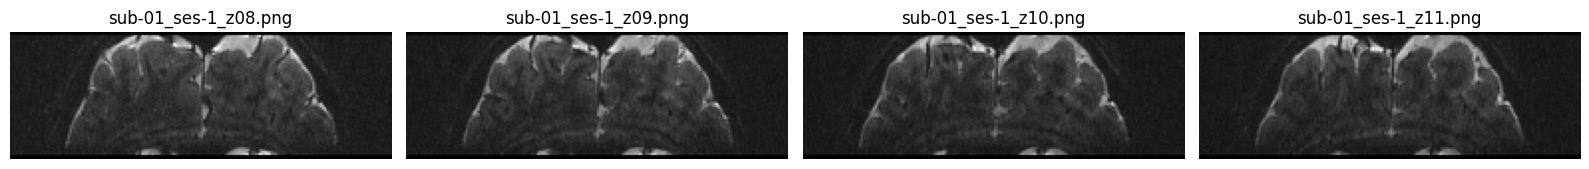

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3))for ax, f in zip(axes, train_files[:4]):    ax.imshow(load_gray(os.path.join(TRAIN_DIR, f)), cmap="gray")    ax.set_title(f, fontsize=9); ax.axis("off")plt.tight_layout(); plt.show()

Slices are 192x64 - a wide rectangle, not a square. Centre-cropping would discard real lateralbrain tissue, so the DDRM study resized to 128x128 instead and reported metrics in that space.The same convention is used here so the numbers stay comparable.

In [ ]:
gt128      = [to_square(load_gray(os.path.join(TRAIN_DIR, f))) for f in train_files]gt128_test = [to_square(load_gray(os.path.join(TEST_DIR,  f))) for f in test_files]print(f"train {len(gt128)} x {gt128[0].shape} | test {len(gt128_test)} x {gt128_test[0].shape}")

## 3. Degradation operatorAn MR scanner acquiring a low-resolution image samples fewer k-space lines, so the physicallycorrect forward operator is frequency-domain truncation rather than spatial averaging. This isthe same operator implemented for DDRM in `src/kspace_truncation.py` of the companion repo,expressed here directly with an FFT.The Hartley-transform construction used there is not needed at this point: it exists onlybecause DDRM requires real SVD matrices, and this notebook merely generates degraded inputs.The retained frequency set is identical - the `r` lowest per axis, closed under `u <-> N-u`.At 4x on a 128x128 image that leaves 31x31 = 961 coefficients.

In [ ]:
def kspace_mask(shape=(SIZE, SIZE), ratio=RATIO):    H, W = shape    rh, rw = H // (2 * ratio), W // (2 * ratio)    ih, iw = np.arange(H), np.arange(W)    keep_h = (ih < rh) | (ih > H - rh)     # 0, +/-1 .. +/-(rh-1): conjugate symmetric    keep_w = (iw < rw) | (iw > W - rw)    return keep_h[:, None] & keep_w[None, :]def kspace_truncate(img_2d, ratio=RATIO):    """Measure the low-frequency block of k-space, discard everything else."""    mask = kspace_mask(img_2d.shape, ratio)    k = np.fft.fft2(img_2d)                # no fftshift - DC sits at index 0    return np.abs(np.fft.ifft2(k * mask))m = kspace_mask()print(f"retained coefficients at {RATIO}x: {m.sum()} / {m.size} ({100*m.sum()/m.size:.1f}%)")

In [ ]:
g = gt128[0]fig, axes = plt.subplots(1, 3, figsize=(13, 4))for ax, (title, im) in zip(axes, [    ("Ground truth", g),    ("k-space truncation 2x", kspace_truncate(g, 2)),    ("k-space truncation 4x", kspace_truncate(g, 4)),]):    ax.imshow(im, cmap="gray", vmin=0, vmax=1); ax.set_title(title); ax.axis("off")plt.tight_layout(); plt.show()

The artifact signature is smooth blur plus Gibbs ringing along the brain/background boundary -what radiologists know as a truncation artifact. Random undersampling would instead producecoherent aliasing replicas, a different inverse problem.

## 4. VAE reconstruction ceilingStable Diffusion never operates on pixels directly: every output passes through a VAEencode/decode round trip, and that round trip is lossy. Its reconstruction PSNR is therefore ahard upper bound on the whole method, regardless of how well the diffusion model performs.SD 1.5's VAE was trained on natural RGB photographs, and 7T EPI data is far outside thatdistribution, so the bound is worth measuring before committing to any training. It is measuredhere at three upsampling factors, since latent resolution is the dominant variable.

In [ ]:
from diffusers import AutoencoderKLvae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae").to(device).eval()vae.requires_grad_(False)SF = vae.config.scaling_factor@torch.no_grad()def vae_ceiling(img_np, scale=SCALE):    """GT -> upsample -> VAE round trip -> back to 128x128 -> PSNR."""    x0 = torch.from_numpy(img_np)[None, None].to(device)    x  = F.interpolate(x0, scale_factor=scale, mode="bicubic", align_corners=False).clamp(0, 1)    rec = vae.decode(vae.encode(x.repeat(1, 3, 1, 1) * 2 - 1).latent_dist.mode()).sample    rec = ((rec + 1) / 2).clamp(0, 1).mean(1, keepdim=True)    back = F.interpolate(rec, size=x0.shape[-2:], mode="bicubic", align_corners=False).clamp(0, 1)    return 10 * np.log10(1.0 / F.mse_loss(back, x0).item())base = [psnr(g, kspace_truncate(g)) for g in gt128[:100]]print(f"zero-filled baseline (train, {RATIO}x): {np.mean(base):.2f} +/- {np.std(base):.2f} dB\n")for s in (1, 2, 4):    vals = [vae_ceiling(g, s) for g in gt128[:30]]    print(f"VAE ceiling  scale={s}x  input {SIZE*s}x{SIZE*s}  latent {SIZE*s//8}x{SIZE*s//8}"          f"  ->  {np.mean(vals):.2f} dB")

zero-filled baseline (train, 4x): 28.39 +/- 0.91 dB

VAE ceiling  scale=1x  input 128x128  latent 16x16  ->  29.43 dB
VAE ceiling  scale=2x  input 256x256  latent 32x32  ->  36.16 dB
VAE ceiling  scale=4x  input 512x512  latent 64x64  ->  44.29 dB


At native resolution the ceiling is only ~1 dB above the untouched degraded image, which wouldleave the method no room at all. `scale=2` lifts it to 36 dB - roughly 8 dB of headroom overthe baseline - and `scale=4` adds another 8 dB for four times the compute, which is not needed.**All experiments below use `scale=2`: 256x256 pixels, 32x32 latent.**

## 5. Baselines on the held-out setThe number to beat is the degraded image itself: a blurred reconstruction already scores wellon pixel-wise metrics, which is exactly what makes this problem interesting.

In [ ]:
for r in (2, 4):    v = [psnr(g, kspace_truncate(g, r)) for g in gt128_test]    print(f"zero-filled {r}x : {np.mean(v):.2f} +/- {np.std(v):.2f} dB   (n={len(v)})")print("\nDDRM reference (same data, same geometry, noise-free): 2x -> 33.14 dB | 4x -> 28.41 dB")

TEST seti zero-filled 2x baseline: 33.67 +/- 1.18 dB  (n=288)
TEST seti zero-filled 4x baseline: 28.88 +/- 1.24 dB  (n=288)

Repo DDRM: 2x -> 33.14 dB | 4x -> 28.41 dB (noise-free)


Worth recording: on this test set the untouched zero-filled reconstruction scores *above* thepublished DDRM numbers at both factors. DDRM was run with `eta=0.85`, so its sampler injectsnoise and synthesises detail that is plausible but not pixel-aligned, and MSE penalises exactlythat. This is the perception-distortion trade-off, and it is the reason the evaluation belowreports LPIPS alongside PSNR and SSIM rather than PSNR alone.

## 6. Paired datasetDegradation is applied on the fly rather than precomputed, so it stays a single source of truthshared by training and evaluation. Ground truth is held in RAM (768 x 128x128 float32, ~50 MB),which removes disk I/O from the loop. `num_workers=0` avoids Windows multiprocessing issues.

In [ ]:
class MRIPairDataset(Dataset):    def __init__(self, gt_cache, ratio=RATIO):        self.gt, self.ratio = gt_cache, ratio    def __len__(self):        return len(self.gt)    def __getitem__(self, idx):        g  = self.gt[idx]        lr = kspace_truncate(g, self.ratio).astype(np.float32)        return {"gt": torch.from_numpy(g)[None].float(),                "lr": torch.from_numpy(lr)[None].float()}train_dataset    = MRIPairDataset(gt128)train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)b = next(iter(train_dataloader))print("gt:", tuple(b["gt"].shape), "| lr:", tuple(b["lr"].shape))print(f"gt range [{b['gt'].min():.3f}, {b['gt'].max():.3f}]")print(f"lr range [{b['lr'].min():.3f}, {b['lr'].max():.3f}]")

gt: torch.Size([4, 1, 128, 128]) | lr: torch.Size([4, 1, 128, 128])
gt [min,max]: 0.0 0.9960784316062927
lr [min,max]: 5.889831300009973e-06 0.7965388298034668


The degraded image peaks lower than the ground truth. Truncation preserves low-frequency energybut removes the high-frequency content that produces bright edges, so peak intensity drops. Norenormalisation is applied - a genuine low-resolution acquisition behaves the same way, andcompensating for it is part of what the model has to learn.

## 7. ModelTwo modifications to SD 1.5:**Channel conditioning.** `conv_in` is widened from 4 to 8 channels and the degraded latent isconcatenated to the noisy latent at every step. This differs from img2img, where the degradedimage only sets the starting point and can drift away during denoising; here the condition isre-supplied at every step and cannot be forgotten. The new weights are zero-initialised, so themodel starts out behaving exactly like stock SD and learns to use the condition gradually -the same idea as ControlNet's zero convolutions.**No text conditioning.** Every image belongs to one class, so a fixed prompt carries noinformation. The empty-string embedding is computed once and frozen, and the text encoder isfreed.LoRA is applied to the attention projections; `conv_in` is trained in full and saved alongsidethe adapters via `modules_to_save`.

In [ ]:
from diffusers import UNet2DConditionModel, DDPMSchedulerfrom transformers import CLIPTextModel, CLIPTokenizerfrom peft import LoraConfig, get_peft_modeldef widen_conv_in(unet):    """4 -> 8 input channels; conditioning weights start at zero."""    old = unet.conv_in    new = torch.nn.Conv2d(8, old.out_channels, old.kernel_size, old.stride, old.padding)    with torch.no_grad():        new.weight.zero_()        new.weight[:, :4] = old.weight     # first 4 channels keep pretrained weights        new.bias.copy_(old.bias)           # last 4 stay zero -> condition initially ignored    unet.conv_in = new    unet.config.in_channels = 8    return unetunet = widen_conv_in(UNet2DConditionModel.from_pretrained(MODEL_ID, subfolder="unet")).to(device)noise_scheduler = DDPMScheduler.from_pretrained(MODEL_ID, subfolder="scheduler")print("conv_in:", tuple(unet.conv_in.weight.shape))tokenizer    = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder="tokenizer")text_encoder = CLIPTextModel.from_pretrained(MODEL_ID, subfolder="text_encoder").to(device).eval()with torch.no_grad():    ids = tokenizer([""], padding="max_length", max_length=tokenizer.model_max_length,                    truncation=True, return_tensors="pt").input_ids.to(device)    EMPTY_EMB = text_encoder(ids)[0]del text_encoder; torch.cuda.empty_cache()print("empty embedding:", tuple(EMPTY_EMB.shape))unet.requires_grad_(False)unet = get_peft_model(unet, LoraConfig(    r=16, lora_alpha=16, init_lora_weights="gaussian",    target_modules=["to_k", "to_q", "to_v", "to_out.0"],    modules_to_save=["conv_in"],))unet.print_trainable_parameters()

conv_in: (320, 8, 3, 3)
empty embedding: (1, 77, 768)
trainable params: 3,212,096 || all params: 862,744,580 || trainable%: 0.3723


## 8. TrainingMixed precision uses bfloat16 autocast with fp32 master weights, not pure fp16. bf16 shares theexponent range of fp32, so no gradient scaler is needed and small gradients do not flush tozero - a failure mode that stalls the loss when the whole model is held in fp16.Note that the diffusion loss is a poor progress signal: a random timestep is drawn per sample,so the curve is dominated by that sampling noise. Real evaluation happens in section 10.

In [ ]:
import time@torch.no_grad()def encode(x01):    """[B,1,128,128] in [0,1] -> [B,4,32,32] scaled latent."""    x = F.interpolate(x01, scale_factor=SCALE, mode="bicubic", align_corners=False).clamp(0, 1)    return vae.encode(x.repeat(1, 3, 1, 1) * 2 - 1).latent_dist.sample() * SFEPOCHS = 50params    = [p for p in unet.parameters() if p.requires_grad]optimizer = torch.optim.AdamW(params, lr=1e-4, weight_decay=1e-2)lr_sched  = torch.optim.lr_scheduler.CosineAnnealingLR(    optimizer, T_max=EPOCHS * len(train_dataloader))unet.train()history, t0 = [], time.time()for epoch in range(EPOCHS):    running = 0.0    pbar = tqdm(train_dataloader, desc=f"epoch {epoch+1}/{EPOCHS}", leave=False)    for batch in pbar:        lat_gt = encode(batch["gt"].to(device))        lat_lr = encode(batch["lr"].to(device))          # condition, never noised        noise = torch.randn_like(lat_gt)        t     = torch.randint(0, noise_scheduler.config.num_train_timesteps,                              (lat_gt.shape[0],), device=device).long()        noisy = noise_scheduler.add_noise(lat_gt, noise, t)        model_in = torch.cat([noisy, lat_lr], dim=1)     # [B, 8, 32, 32]        emb      = EMPTY_EMB.expand(lat_gt.shape[0], -1, -1)        with torch.autocast("cuda", dtype=torch.bfloat16):            pred = unet(model_in, t, encoder_hidden_states=emb).sample            loss = F.mse_loss(pred.float(), noise.float())        optimizer.zero_grad(set_to_none=True)        loss.backward()        torch.nn.utils.clip_grad_norm_(params, 1.0)        optimizer.step()        lr_sched.step()        running += loss.item()        pbar.set_postfix(loss=f"{loss.item():.4f}")    history.append(running / len(train_dataloader))    if (epoch + 1) % 5 == 0 or epoch == 0:        print(f"epoch {epoch+1:3d} | loss {history[-1]:.4f} | {(time.time()-t0)/60:.1f} min")    if (epoch + 1) % 25 == 0:        ckpt = f"mri_sd_lora_ep{epoch+1}"        unet.save_pretrained(ckpt)        torch.save({"opt": optimizer.state_dict(), "sched": lr_sched.state_dict(),                    "epoch": epoch + 1, "history": history}, f"{ckpt}/train_state.pt")unet.save_pretrained("mri_sd_lora_final")print(f"done in {(time.time()-t0)/60:.1f} min")

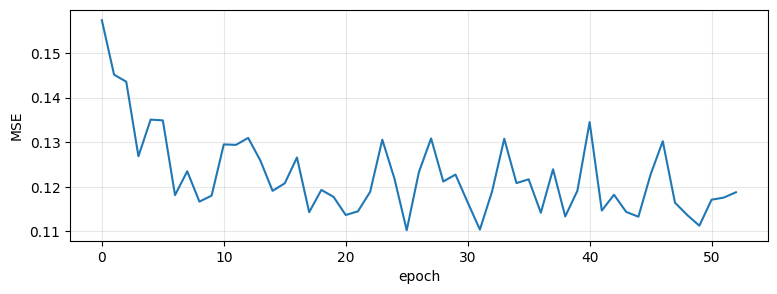

ilk: 0.1574 | son: 0.1188 | min: 0.1103


In [ ]:
plt.figure(figsize=(9, 3))plt.plot(history); plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.grid(alpha=.3)plt.tight_layout(); plt.show()print(f"first {history[0]:.4f} | last {history[-1]:.4f} | min {min(history):.4f}")

## 9. Inference**Data consistency.** After decoding, the measured k-space coefficients are written back intothe prediction, leaving the model free to synthesise only the frequencies that were neveracquired. Without this the output is merely plausible; with it the output cannot contradict themeasurement. This is a simplified version of what DDRM enforces analytically.It is applied once at the end rather than at every step: enforcing it per step would require aVAE round trip each time, and that round trip is itself lossy (~36 dB), so the error wouldaccumulate over 50 steps.

In [ ]:
from diffusers import DDIMSchedulerfrom peft import PeftModeldef data_consistency(x_hat, lr_img, mask):    K = np.fft.fft2(x_hat) * (~mask) + np.fft.fft2(lr_img) * mask    return np.clip(np.real(np.fft.ifft2(K)), 0, 1)@torch.no_grad()def restore(lr_np, model, n_steps=50, seed=0, apply_dc=True):    sched = DDIMScheduler.from_pretrained(MODEL_ID, subfolder="scheduler")    sched.set_timesteps(n_steps, device=device)    lat_lr = encode(torch.from_numpy(lr_np)[None, None].float().to(device))    gen    = torch.Generator(device=device).manual_seed(seed)    lat    = torch.randn(lat_lr.shape, generator=gen, device=device) * sched.init_noise_sigma    for t in sched.timesteps:        with torch.autocast("cuda", dtype=torch.bfloat16):            eps = model(torch.cat([lat, lat_lr], dim=1), t,                        encoder_hidden_states=EMPTY_EMB).sample.float()        lat = sched.step(eps, t, lat).prev_sample    img = vae.decode(lat / SF).sample    img = ((img + 1) / 2).clamp(0, 1).mean(1, keepdim=True)    img = F.interpolate(img, size=(SIZE, SIZE), mode="bicubic", align_corners=False).clamp(0, 1)    out = img[0, 0].cpu().numpy()    return data_consistency(out, lr_np, kspace_mask()) if apply_dc else outdef restore_avg(lr_np, model, n_avg=1, n_steps=50, apply_dc=True):    """Average n_avg stochastic samples, then apply data consistency once."""    acc = np.zeros((SIZE, SIZE), np.float64)    for s in range(n_avg):        acc += restore(lr_np, model, n_steps=n_steps, seed=s, apply_dc=False)    out = (acc / n_avg).astype(np.float32)    return data_consistency(out, lr_np, kspace_mask()) if apply_dc else out

In [ ]:
CKPT = "mri_sd_lora_ep50"unet_test = widen_conv_in(UNet2DConditionModel.from_pretrained(MODEL_ID, subfolder="unet"))unet_test = PeftModel.from_pretrained(unet_test.to(device), CKPT).eval()print("loaded:", CKPT)

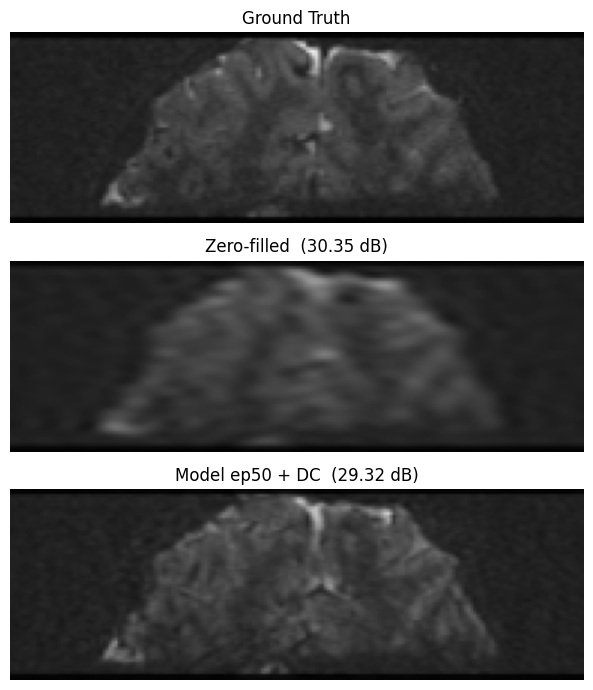

In [ ]:
g   = gt128_test[0]lr_ = kspace_truncate(g).astype(np.float32)out = restore(lr_, unet_test)fig, axes = plt.subplots(3, 1, figsize=(11, 7))for ax, (t, im) in zip(axes, [    ("Ground truth", g),    (f"Zero-filled  ({psnr(g, lr_):.2f} dB)", lr_),    (f"Model + data consistency  ({psnr(g, out):.2f} dB)", out)]):    ax.imshow(to_native(im), cmap="gray", vmin=0, vmax=1)    ax.set_title(t, fontsize=10, loc="left"); ax.axis("off")plt.tight_layout(); plt.show()

The conditioning works: the output is the same slice, not an invented brain. It also reproducesthe granular texture of the ground truth, which the zero-filled reconstruction has lostentirely - the expected behaviour once a diffusion model has learned the data distribution.It nevertheless scores below the blurred input on PSNR, because that texture is statisticallyright but not pixel-aligned.

## 10. EvaluationThree metrics, because no single one captures this problem. PSNR and SSIM measure fidelity andreward blur; LPIPS measures perceptual distance and rewards realistic texture (lower is better).

In [ ]:
from skimage.metrics import structural_similarity as ssim_fnimport lpips, pandas as pdlpips_fn = lpips.LPIPS(net="alex").to(device)def to_lpips(x):    t = torch.from_numpy(np.ascontiguousarray(x))[None, None].float().to(device)    return t.repeat(1, 3, 1, 1) * 2 - 1def score(gt, im):    return {"psnr":  psnr(gt, im),            "ssim":  ssim_fn(gt, im, data_range=1.0),            "lpips": lpips_fn(to_lpips(gt), to_lpips(im)).item()}rows = []for g_ in tqdm(gt128_test[:30]):    lr_i = kspace_truncate(g_).astype(np.float32)    variants = [("zero-filled", lr_i),                ("model",       restore(lr_i, unet_test, apply_dc=False)),                ("model+DC",    restore(lr_i, unet_test, apply_dc=True))]    for name, im in variants:        rows.append({"method": name, **score(g_, im)})print(pd.DataFrame(rows).groupby("method")[["psnr", "ssim", "lpips"]]        .agg(["mean", "std"]).round(4))

                psnr            ssim           lpips        
                mean     std    mean     std    mean     std
method                                                      
model        27.4837  0.6449  0.7280  0.0229  0.0972  0.0158
model+DC     28.2071  0.8270  0.7333  0.0259  0.0949  0.0145
zero-filled  29.7225  0.9684  0.7974  0.0264  0.3646  0.0243


Data consistency improves all three metrics, modestly but consistently. The wider result is thesplit verdict: fidelity metrics prefer the untouched blur while LPIPS prefers the model by afactor of nearly four. Same images, opposite ranking.

## 11. Sample averaging traces the trade-off curveEach sample draws different high-frequency detail, but the underlying anatomy is shared, soaveraging suppresses the invented texture while preserving structure. As the number of samplesgrows the estimate approaches the posterior mean, which by definition minimises squared error -so PSNR is expected to rise and perceptual quality to fall. One knob, one trained model,the whole perception-distortion curve.

In [ ]:
rows = []for g_ in tqdm(gt128_test[:15]):    lr_i = kspace_truncate(g_).astype(np.float32)    rows.append({"N": 0, **score(g_, lr_i)})                 # N=0: zero-filled baseline    for n in (1, 2, 4, 8):        rows.append({"N": n, **score(g_, restore_avg(lr_i, unet_test, n_avg=n))})print(pd.DataFrame(rows).groupby("N")[["psnr", "ssim", "lpips"]].mean().round(4))

      psnr    ssim   lpips
N                         
0  29.9585  0.8033  0.3612
1  28.3486  0.7333  0.0921
2  29.6551  0.7812  0.0857
4  29.8307  0.7871  0.0925
8  30.5454  0.8143  0.1157


| | PSNR | SSIM | LPIPS ||---|---|---|---|| Zero-filled (N=0) | 29.96 | 0.803 | 0.361 || Model, 1 sample | 28.35 | 0.733 | **0.092** || Model, 8 samples | **30.55** | **0.814** | 0.116 |A single sample loses on fidelity and wins decisively on perception. Averaging eight samplesbeats the baseline on all three metrics at once, so the method does not depend on arguing thatLPIPS matters more than PSNR.LPIPS is not monotonic - it bottoms out at N=2 and degrades after. Light averaging removesincorrect texture; heavy averaging removes correct texture too.

## 12. Figures

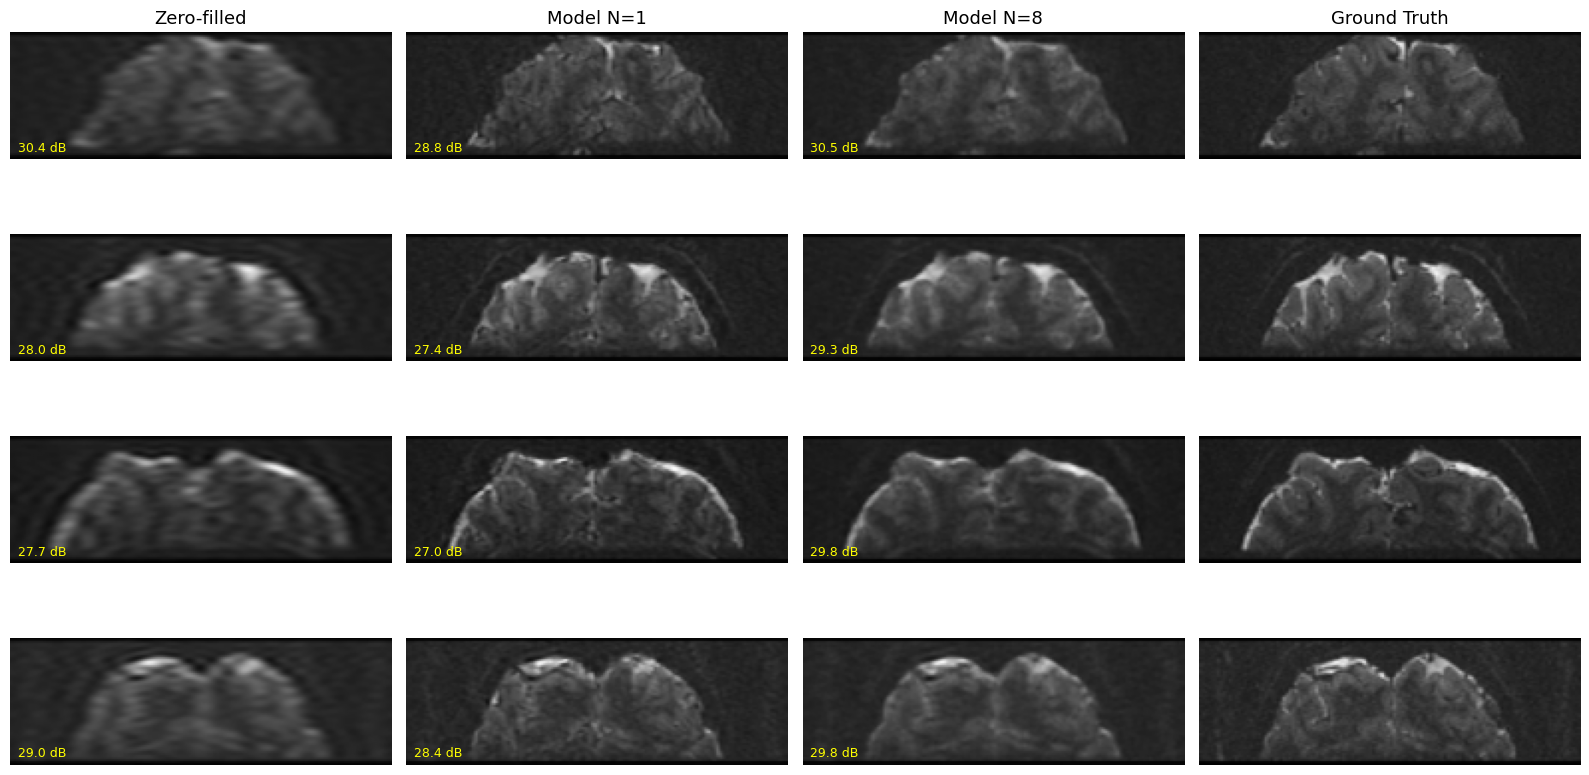

In [ ]:
os.makedirs("figures", exist_ok=True)idxs  = [0, 60, 120, 200]names = ["Zero-filled", "Model N=1", "Model N=8", "Ground truth"]fig, axes = plt.subplots(len(idxs), 4, figsize=(16, 2.2 * len(idxs)))for r, i in enumerate(idxs):    g_   = gt128_test[i]    lr_i = kspace_truncate(g_).astype(np.float32)    ims  = [lr_i,            restore_avg(lr_i, unet_test, n_avg=1),            restore_avg(lr_i, unet_test, n_avg=8),            g_]    for c, (im, name) in enumerate(zip(ims, names)):        axes[r, c].imshow(to_native(im), cmap="gray", vmin=0, vmax=1)        axes[r, c].axis("off")        if r == 0:            axes[r, c].set_title(name, fontsize=13)        if name != "Ground truth":            axes[r, c].text(0.02, 0.06, f"{psnr(g_, im):.1f} dB",                            transform=axes[r, c].transAxes, color="yellow", fontsize=9)plt.tight_layout()plt.savefig("figures/fig1_methods.png", dpi=150, bbox_inches="tight")plt.show()

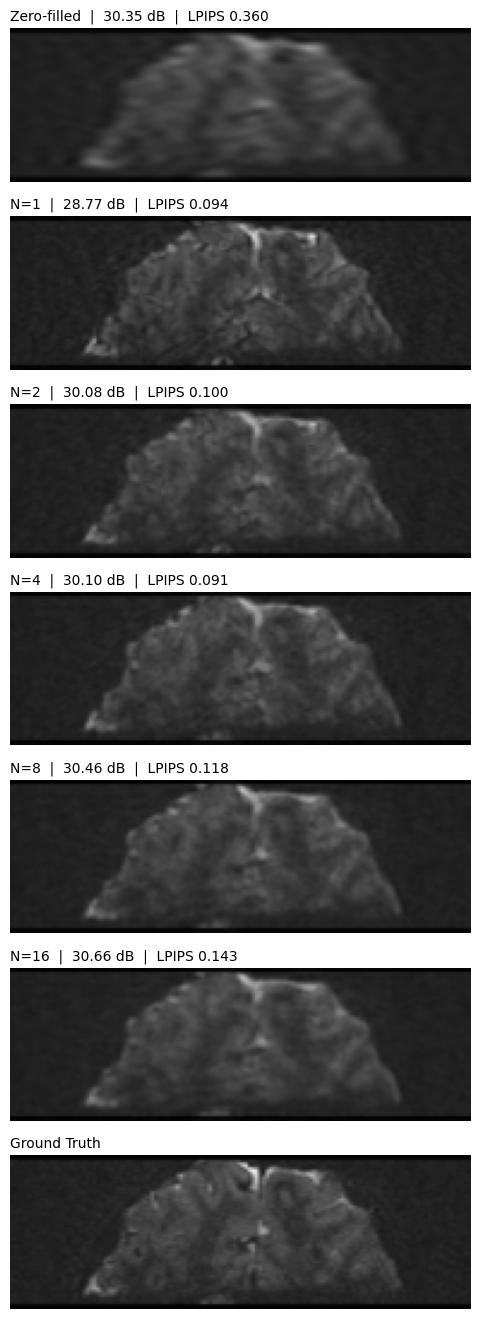

In [ ]:
g_    = gt128_test[0]lr_i  = kspace_truncate(g_).astype(np.float32)cache = {n: restore_avg(lr_i, unet_test, n_avg=n) for n in (1, 2, 4, 8, 16)}panels = ([("Zero-filled", lr_i)]          + [(f"N={n}", cache[n]) for n in (1, 2, 4, 8, 16)]          + [("Ground truth", g_)])fig, axes = plt.subplots(len(panels), 1, figsize=(11, 1.9 * len(panels)))for ax, (name, im) in zip(axes, panels):    ax.imshow(to_native(im), cmap="gray", vmin=0, vmax=1); ax.axis("off")    tag = name if name == "Ground truth" else (        f"{name}  |  {psnr(g_, im):.2f} dB  |  "        f"LPIPS {lpips_fn(to_lpips(g_), to_lpips(im)).item():.3f}")    ax.set_title(tag, fontsize=10, loc="left")plt.tight_layout()plt.savefig("figures/fig2_sample_averaging.png", dpi=150, bbox_inches="tight")plt.show()

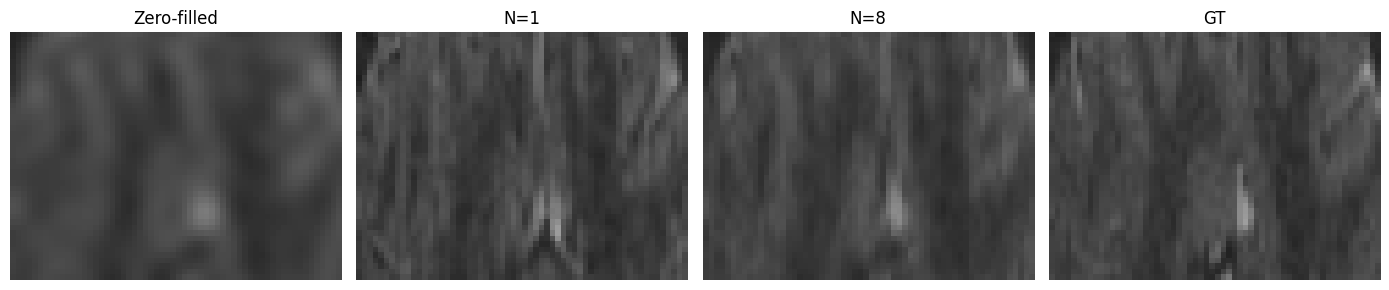

In [ ]:
y0, x0, h, w = 30, 35, 45, 60crop = lambda im: im[y0:y0+h, x0:x0+w]row = [("Zero-filled", lr_i), ("N=1", cache[1]), ("N=8", cache[8]), ("Ground truth", g_)]fig, axes = plt.subplots(1, 4, figsize=(14, 4))for ax, (name, im) in zip(axes, row):    ax.imshow(crop(im), cmap="gray", vmin=0, vmax=1); ax.set_title(name); ax.axis("off")plt.tight_layout()plt.savefig("figures/fig3_detail.png", dpi=150, bbox_inches="tight")plt.show()print("saved:", sorted(os.listdir("figures")))

## Limitations- Trained for 50 epochs; no saturation study against the 25-epoch checkpoint.- Metrics computed on 15-30 held-out slices rather than all 288; differences of a few tenths  of a dB are within noise at that sample size.- One degradation factor (4x), noise-free only. The companion DDRM study found the largest  advantage under measurement noise, which is untested here.- Data consistency is applied once after decoding, not at every denoising step.- Single trained model, single LoRA rank; no seed-variance or hyperparameter study.- Metrics are computed in the resized 128x128 space, so relative comparisons are meaningful but  absolute values are not native-resolution numbers.